# Questionnaire Analysis — Between Conditions

Compares survey responses across visualization conditions (control, single-turn, multi-turn),
controlling for prompt order. Uses the final analysis set (228 participants).

Survey items:
- **Pre-survey** (1-7 Likert): predictability, negative predictability, trust
- **Final survey — Core Likert** (all conditions): predictability post, negative predictability post, trust post
- **Final survey — Viz Likert** (conditions 1-2): helpfulness, anticipation, prediction, referenced, confidence, frequency, comprehension
- **Final survey — Drift** (condition 2 only): drift panel helpful
- **Final survey — UEQ** (conditions 1-2): 8 semantic differential items
- **MBA/MBE trait ratings** (-10 to +10): 6 traits per session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('plots/questionnaire', exist_ok=True)

df = pd.read_csv('data_participants.csv')

TRAITS = ['empathy', 'erudite', 'robotic', 'romantic', 'sycophantic', 'toxic']
CONDITION_ORDER = ['control', 'single_turn', 'multi_turn']
CONDITION_COLORS = {'control': '#888888', 'single_turn': '#2196F3', 'multi_turn': '#E91E63'}
CONDITION_LABELS = {'control': 'Control', 'single_turn': 'Single-Turn', 'multi_turn': 'Multi-Turn'}

print(f'Participants: {len(df)}')
print(f'By condition: {df["condition_name"].value_counts().to_dict()}')
print(f'By prompt order: {df["prompt_order"].value_counts().to_dict()}')

Participants: 228
By condition: {'single_turn': 85, 'multi_turn': 80, 'control': 63}
By prompt order: {'asst_first': 116, 'roleply_first': 112}


In [2]:
def kruskal_test(data, col, group_col='condition_name'):
    groups = [grp[col].dropna().values for _, grp in data.groupby(group_col) if len(grp[col].dropna()) > 0]
    if len(groups) < 2:
        return np.nan, np.nan
    h, p = stats.kruskal(*groups)
    return h, p


def mann_whitney_pairs(data, col, conditions=None, group_col='condition_name'):
    if conditions is None:
        conditions = [c for c in CONDITION_ORDER if c in data[group_col].values]
    results = []
    for i in range(len(conditions)):
        for j in range(i + 1, len(conditions)):
            a = data[data[group_col] == conditions[i]][col].dropna()
            b = data[data[group_col] == conditions[j]][col].dropna()
            if len(a) > 0 and len(b) > 0:
                u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
                results.append((conditions[i], conditions[j], u, p))
    return results


def print_stats(data, col, label, conditions=None):
    if conditions is None:
        conditions = CONDITION_ORDER
    present = [c for c in conditions if c in data['condition_name'].values]

    if len(present) >= 2:
        h, p = kruskal_test(data, col)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f'\n  {label}  (Kruskal-Wallis H={h:.2f}, p={p:.4f}) {sig}')
    else:
        print(f'\n  {label}')

    for cond in present:
        vals = data[data['condition_name'] == cond][col].dropna()
        if len(vals) > 0:
            print(f'    {CONDITION_LABELS[cond]:12s}: n={len(vals):2d}, '
                  f'mean={vals.mean():.2f}, median={vals.median():.1f}, std={vals.std():.2f}')

    if len(present) >= 2:
        pairs = mann_whitney_pairs(data, col, present)
        for c1, c2, u, p_mw in pairs:
            sig_mw = '*' if p_mw < 0.05 else ''
            print(f'    {CONDITION_LABELS[c1]} vs {CONDITION_LABELS[c2]}: '
                  f'U={u:.0f}, p={p_mw:.4f} {sig_mw}')


def plot_bars(data, columns, labels, title, filename, hue_order=None, palette=None, ylabel='Rating (1-7)', figsize=None):
    if hue_order is None:
        hue_order = [c for c in CONDITION_ORDER if c in data['condition_name'].values]
    if palette is None:
        palette = CONDITION_COLORS
    n = len(columns)
    if figsize is None:
        figsize = (max(8, n * 2.5), 5)

    id_cols = ['firebase_id', 'condition_name', 'prompt_order']
    df_long = data[id_cols + columns].melt(id_vars=id_cols, var_name='item', value_name='rating')
    df_long['item_label'] = df_long['item'].map(dict(zip(columns, labels)))

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=df_long, x='item_label', y='rating', hue='condition_name',
                hue_order=hue_order, palette=palette, ax=ax, errorbar='se', capsize=0.05)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    if n > 4:
        ax.tick_params(axis='x', rotation=25)
    handles, hlabels = ax.get_legend_handles_labels()
    ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in hlabels], fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plots/questionnaire/{filename}', bbox_inches='tight')
    plt.show()

## 1. Pre-Survey (Baseline — Before Any Sessions)

Randomization check: these should NOT differ by condition.

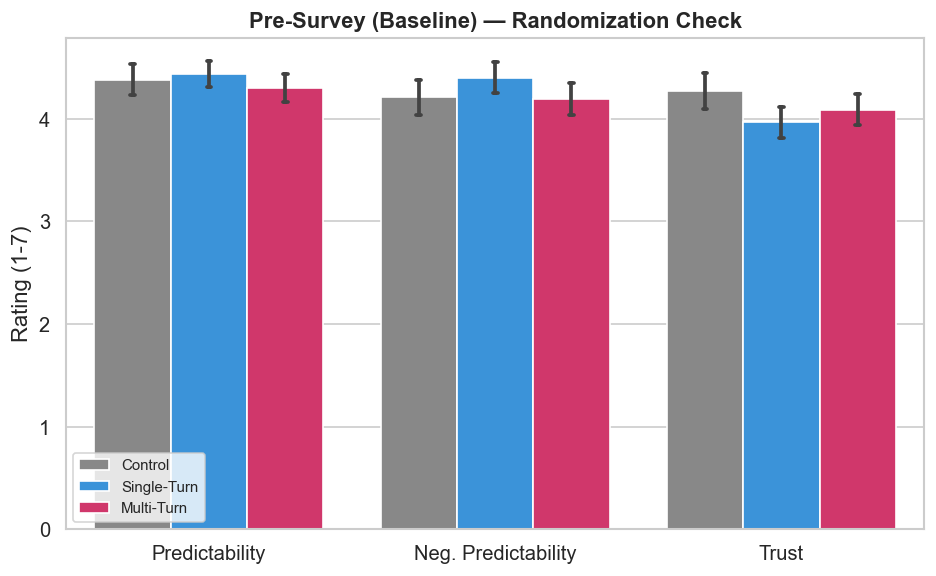

--- Pre-Survey: Randomization Check ---

  Predictability  (Kruskal-Wallis H=0.40, p=0.8173) 
    Control     : n=63, mean=4.38, median=4.0, std=1.17
    Single-Turn : n=85, mean=4.44, median=4.0, std=1.16
    Multi-Turn  : n=80, mean=4.30, median=4.0, std=1.19
    Control vs Single-Turn: U=2590, p=0.7263 
    Control vs Multi-Turn: U=2579, p=0.8058 
    Single-Turn vs Multi-Turn: U=3586, p=0.5319 

  Neg. Predictability  (Kruskal-Wallis H=1.12, p=0.5702) 
    Control     : n=63, mean=4.21, median=4.0, std=1.33
    Single-Turn : n=85, mean=4.40, median=4.0, std=1.38
    Multi-Turn  : n=80, mean=4.19, median=4.0, std=1.39
    Control vs Single-Turn: U=2454, p=0.3742 
    Control vs Multi-Turn: U=2516, p=0.9884 
    Single-Turn vs Multi-Turn: U=3675, p=0.3601 

  Trust  (Kruskal-Wallis H=1.82, p=0.4029) 
    Control     : n=63, mean=4.27, median=4.0, std=1.41
    Single-Turn : n=85, mean=3.96, median=4.0, std=1.41
    Multi-Turn  : n=80, mean=4.09, median=4.0, std=1.36
    Control vs Sin

In [3]:
pre_cols = ['pre_predictability', 'pre_negative_predictability', 'pre_trust']
pre_labels = ['Predictability', 'Neg. Predictability', 'Trust']

plot_bars(df, pre_cols, pre_labels, 'Pre-Survey (Baseline) — Randomization Check', 'pre_survey.png')

print('--- Pre-Survey: Randomization Check ---')
for col, label in zip(pre_cols, pre_labels):
    print_stats(df, col, label)

## 2. Final Survey — Core Likert (All Conditions)

Post-study reflection after completing both sessions.

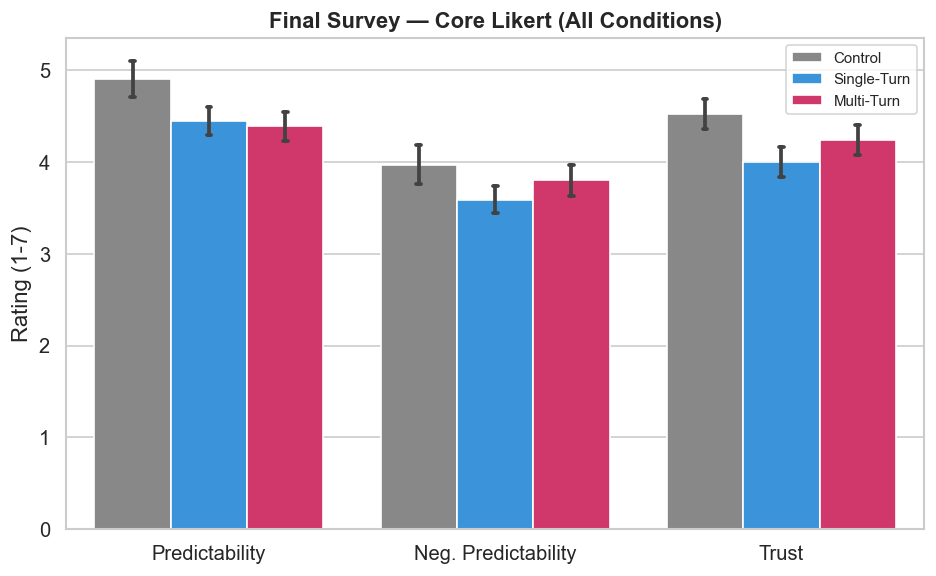

--- Final Survey: Core Likert ---

  Predictability  (Kruskal-Wallis H=5.69, p=0.0582) 
    Control     : n=63, mean=4.90, median=5.0, std=1.53
    Single-Turn : n=85, mean=4.45, median=5.0, std=1.38
    Multi-Turn  : n=80, mean=4.39, median=5.0, std=1.42
    Control vs Single-Turn: U=3184, p=0.0447 *
    Control vs Multi-Turn: U=3044, p=0.0294 *
    Single-Turn vs Multi-Turn: U=3472, p=0.8095 

  Neg. Predictability  (Kruskal-Wallis H=2.29, p=0.3186) 
    Control     : n=63, mean=3.97, median=4.0, std=1.69
    Single-Turn : n=85, mean=3.59, median=4.0, std=1.37
    Multi-Turn  : n=80, mean=3.80, median=4.0, std=1.50
    Control vs Single-Turn: U=3058, p=0.1338 
    Control vs Multi-Turn: U=2670, p=0.5351 
    Single-Turn vs Multi-Turn: U=3131, p=0.3712 

  Trust  (Kruskal-Wallis H=4.13, p=0.1269) 
    Control     : n=63, mean=4.52, median=5.0, std=1.32
    Single-Turn : n=85, mean=4.00, median=4.0, std=1.54
    Multi-Turn  : n=80, mean=4.24, median=5.0, std=1.45
    Control vs Single-

In [4]:
final_cols = ['final_predictability_post', 'final_negative_predictability_post', 'final_trust_post']
final_labels = ['Predictability', 'Neg. Predictability', 'Trust']

plot_bars(df, final_cols, final_labels, 'Final Survey — Core Likert (All Conditions)', 'final_core_likert.png')

print('--- Final Survey: Core Likert ---')
for col, label in zip(final_cols, final_labels):
    print_stats(df, col, label)

## 3. Pre → Final Shift (All Conditions)

Within-subjects change from pre-survey to final survey. Positive = increased after study.

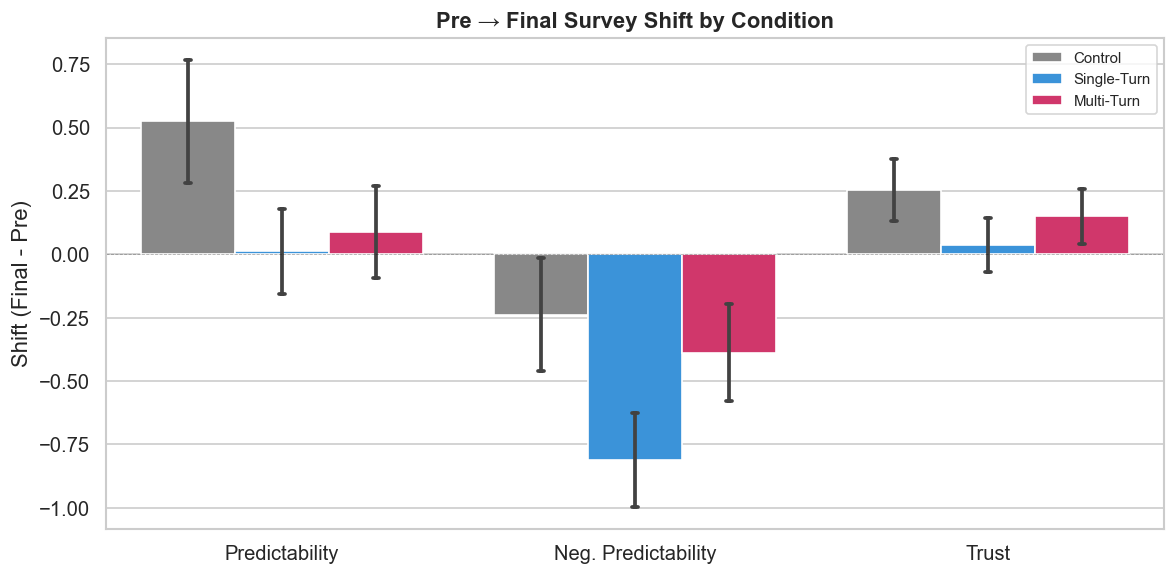

--- Pre → Final Shift ---

  Predictability  (Kruskal-Wallis H=3.78, p=0.1510) 
    Control     : n=63, mean=0.52, median=0.0, std=1.92
    Single-Turn : n=85, mean=0.01, median=0.0, std=1.55
    Multi-Turn  : n=80, mean=0.09, median=0.0, std=1.62
    Control vs Single-Turn: U=3157, p=0.0574 
    Control vs Multi-Turn: U=2855, p=0.1650 
    Single-Turn vs Multi-Turn: U=3239, p=0.5918 
      Wilcoxon (shift≠0): W=324, p=0.0271 *
      Wilcoxon (shift≠0): W=760, p=0.7547 
      Wilcoxon (shift≠0): W=736, p=0.4578 

  Neg. Predictability  (Kruskal-Wallis H=5.35, p=0.0689) 
    Control     : n=63, mean=-0.24, median=0.0, std=1.77
    Single-Turn : n=85, mean=-0.81, median=-1.0, std=1.70
    Multi-Turn  : n=80, mean=-0.39, median=0.0, std=1.71
    Control vs Single-Turn: U=3243, p=0.0255 *
    Control vs Multi-Turn: U=2722, p=0.4033 
    Single-Turn vs Multi-Turn: U=2945, p=0.1308 
      Wilcoxon (shift≠0): W=424, p=0.3988 
      Wilcoxon (shift≠0): W=410, p=0.0001 *
      Wilcoxon (shift≠0

In [5]:
df['shift_predictability'] = df['final_predictability_post'] - df['pre_predictability']
df['shift_neg_predictability'] = df['final_negative_predictability_post'] - df['pre_negative_predictability']
df['shift_trust'] = df['final_trust_post'] - df['pre_trust']

shift_cols = ['shift_predictability', 'shift_neg_predictability', 'shift_trust']
shift_labels = ['Predictability', 'Neg. Predictability', 'Trust']

# Plot
id_cols = ['firebase_id', 'condition_name', 'prompt_order']
df_long = df[id_cols + shift_cols].melt(id_vars=id_cols, var_name='item', value_name='shift')
df_long['item_label'] = df_long['item'].map(dict(zip(shift_cols, shift_labels)))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_long, x='item_label', y='shift', hue='condition_name',
            hue_order=CONDITION_ORDER, palette=CONDITION_COLORS, ax=ax, errorbar='se', capsize=0.05)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('Shift (Final - Pre)')
ax.set_title('Pre → Final Survey Shift by Condition', fontweight='bold')
handles, hlabels = ax.get_legend_handles_labels()
ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in hlabels], fontsize=9)
plt.tight_layout()
plt.savefig('plots/questionnaire/pre_final_shift.png', bbox_inches='tight')
plt.show()

# Stats
print('--- Pre → Final Shift ---')
for col, label in zip(shift_cols, shift_labels):
    print_stats(df, col, label)
    # Within-condition Wilcoxon (is the shift significantly different from 0?)
    for cond in CONDITION_ORDER:
        vals = df[df['condition_name'] == cond][col].dropna()
        if len(vals) > 1 and vals.nunique() > 1:
            try:
                w, p_w = stats.wilcoxon(vals)
                sig = '*' if p_w < 0.05 else ''
                print(f'      Wilcoxon (shift≠0): W={w:.0f}, p={p_w:.4f} {sig}')
            except ValueError:
                pass

## 4. MBA/MBE Trait Ratings — Between Conditions

Session 1 is baseline (no viz), Session 2 is experimental (viz applied).
Controlling for prompt type by faceting.

In [6]:
# Build long-format trait data
trait_rows = []
for _, row in df.iterrows():
    for s in [1, 2]:
        prompt = row[f'session{s}_prompt_type']
        for trait in TRAITS:
            trait_rows.append({
                'firebase_id': row['firebase_id'],
                'condition_name': row['condition_name'],
                'prompt_order': row['prompt_order'],
                'session': s,
                'prompt_type': prompt,
                'trait': trait.capitalize(),
                'mba': row[f's{s}_mba_{trait}'],
                'mbe': row[f's{s}_mbe_{trait}'],
            })

df_traits = pd.DataFrame(trait_rows)
df_traits['mbe_mba_shift'] = df_traits['mbe'] - df_traits['mba']
print(f'Trait data: {len(df_traits)} rows')

Trait data: 2736 rows


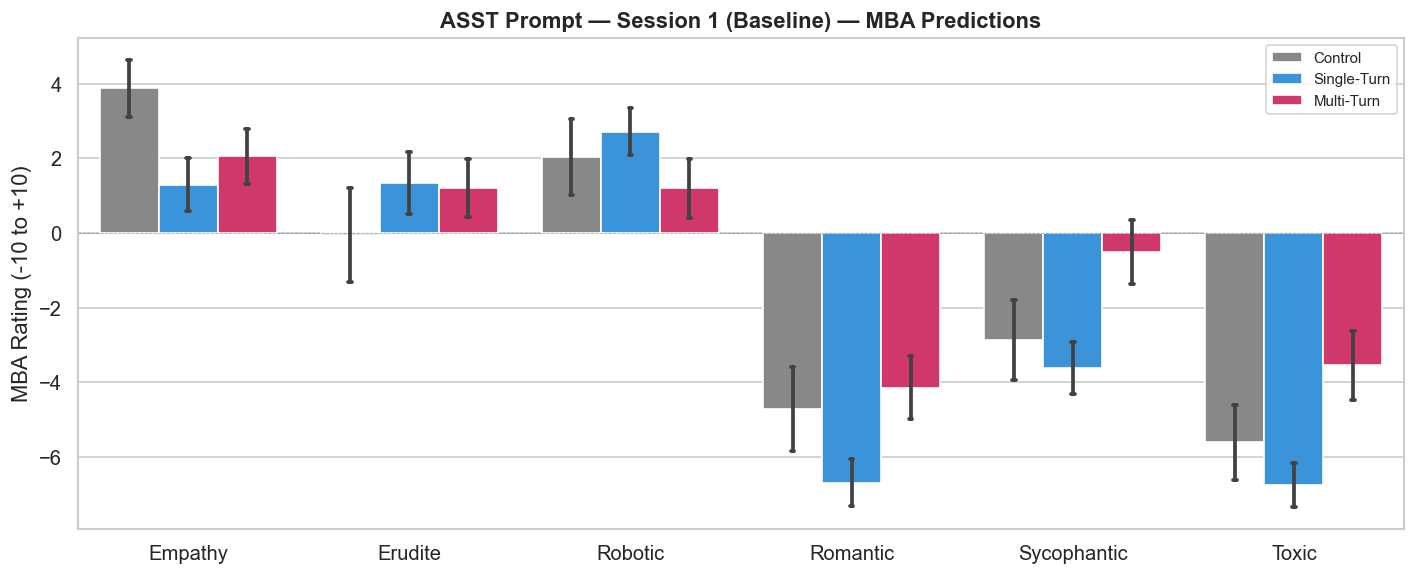

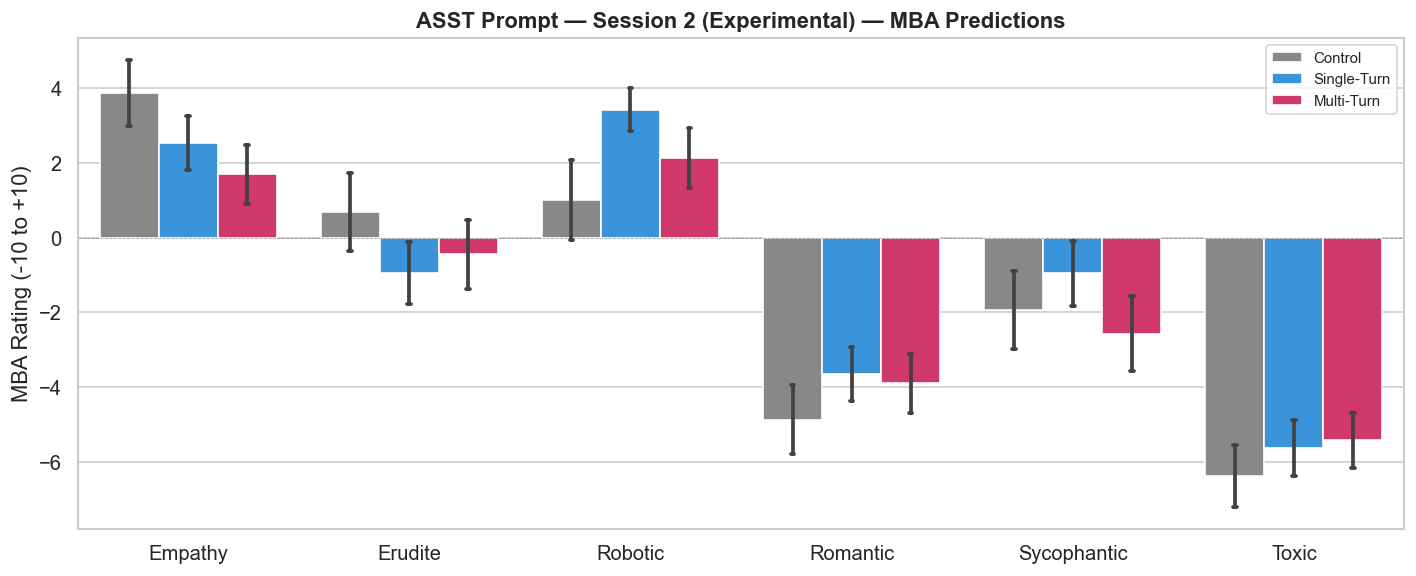

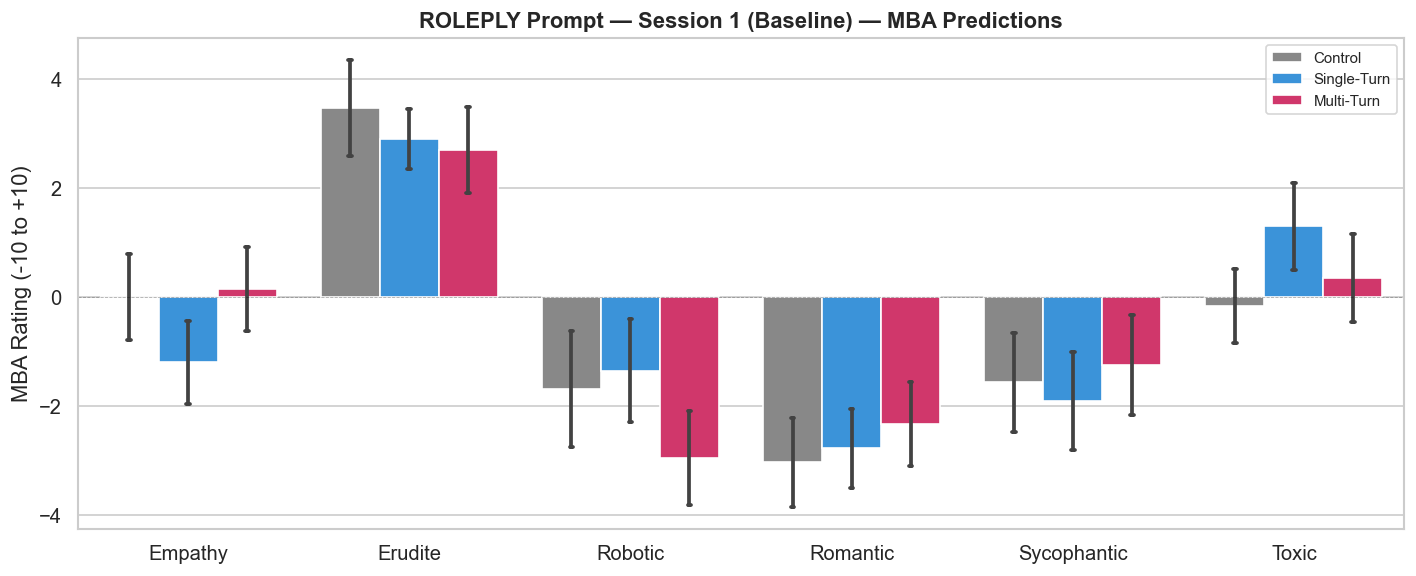

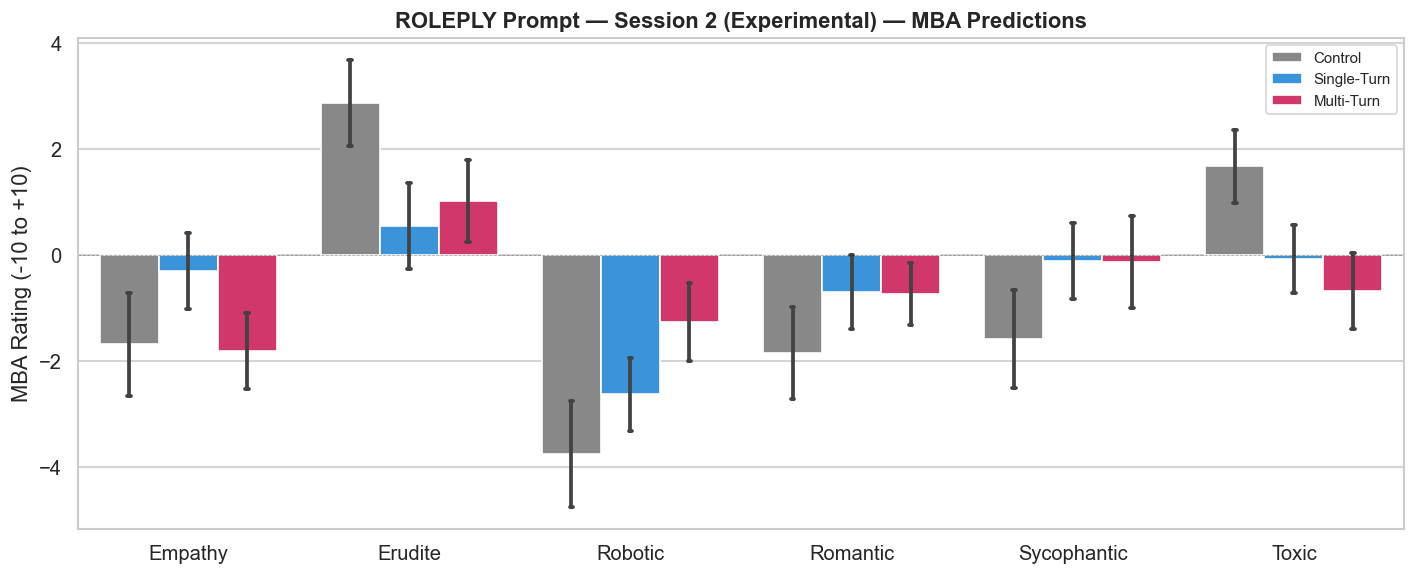

In [7]:
# MBA by condition, faceted by prompt type
for prompt_type in ['ASST', 'ROLEPLY']:
    for session in [1, 2]:
        subset = df_traits[(df_traits['prompt_type'] == prompt_type) & (df_traits['session'] == session)]

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=subset, x='trait', y='mba', hue='condition_name',
                    hue_order=CONDITION_ORDER, palette=CONDITION_COLORS, ax=ax, errorbar='se', capsize=0.05)
        ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
        ax.set_xlabel('')
        ax.set_ylabel('MBA Rating (-10 to +10)')
        viz_note = '(Baseline)' if session == 1 else '(Experimental)'
        ax.set_title(f'{prompt_type} Prompt — Session {session} {viz_note} — MBA Predictions', fontweight='bold')
        handles, hlabels = ax.get_legend_handles_labels()
        ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in hlabels], fontsize=9)
        plt.tight_layout()
        plt.savefig(f'plots/questionnaire/mba_s{session}_{prompt_type.lower()}.png', bbox_inches='tight')
        plt.show()

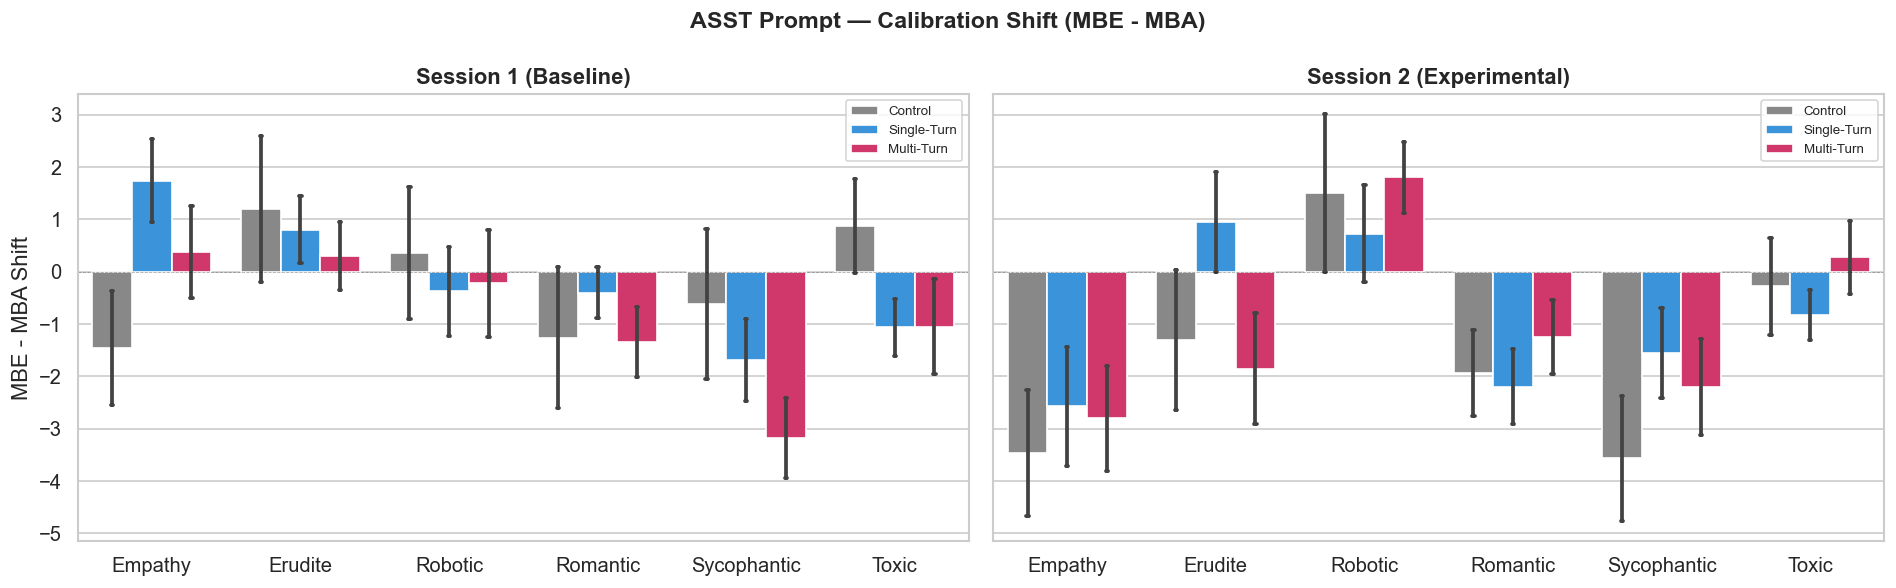

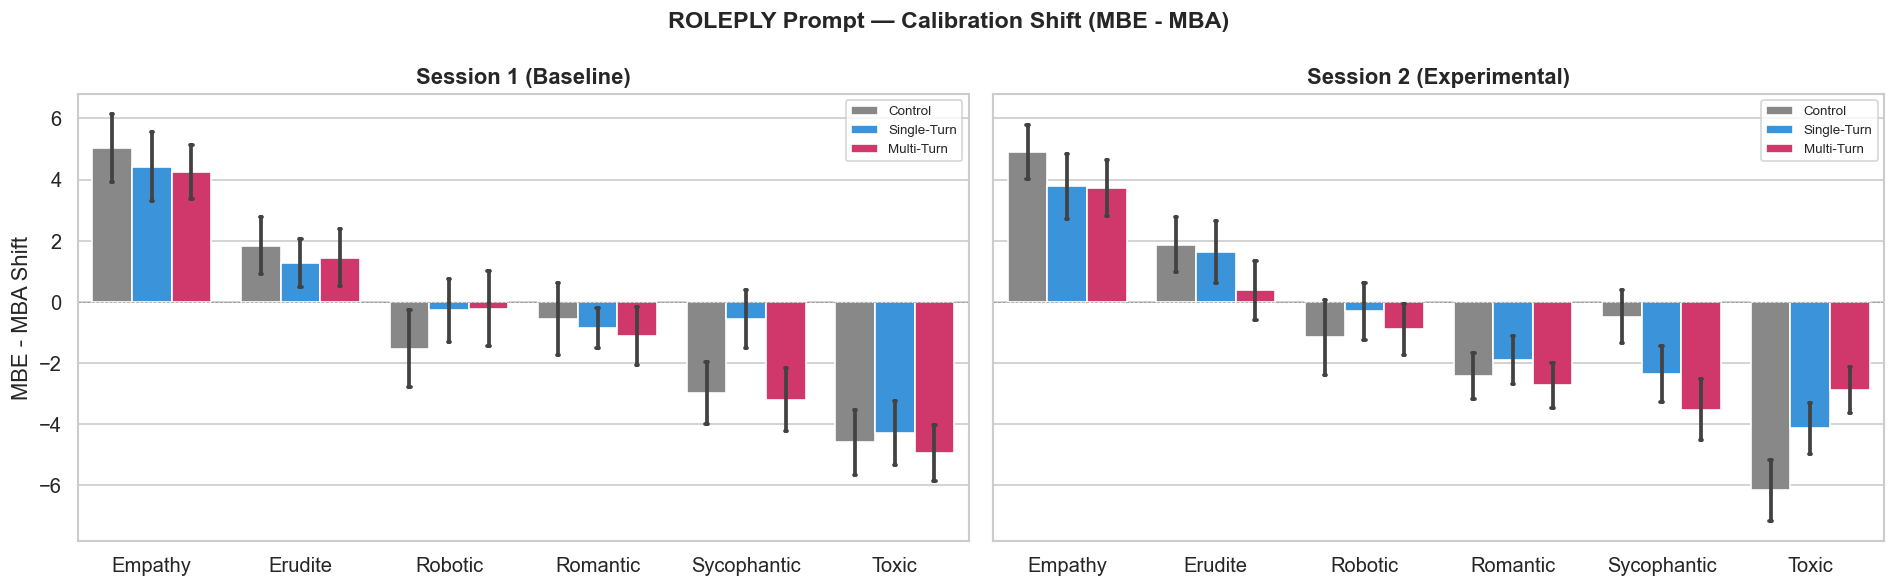

--- MBE-MBA Shift in Session 2 (Experimental) ---

  ASST prompt:
    Empathy     : Control=-3.5, Single-Turn=-2.6, Multi-Turn=-2.8  (H=0.28, p=0.8691) 
    Erudite     : Control=-1.3, Single-Turn=+0.9, Multi-Turn=-1.9  (H=2.74, p=0.2539) 
    Robotic     : Control=+1.5, Single-Turn=+0.7, Multi-Turn=+1.8  (H=0.57, p=0.7528) 
    Romantic    : Control=-1.9, Single-Turn=-2.2, Multi-Turn=-1.2  (H=3.19, p=0.2033) 
    Sycophantic : Control=-3.6, Single-Turn=-1.6, Multi-Turn=-2.2  (H=1.37, p=0.5040) 
    Toxic       : Control=-0.3, Single-Turn=-0.8, Multi-Turn=+0.3  (H=3.47, p=0.1765) 

  ROLEPLY prompt:
    Empathy     : Control=+4.9, Single-Turn=+3.8, Multi-Turn=+3.7  (H=0.82, p=0.6624) 
    Erudite     : Control=+1.9, Single-Turn=+1.6, Multi-Turn=+0.4  (H=2.28, p=0.3192) 
    Robotic     : Control=-1.2, Single-Turn=-0.3, Multi-Turn=-0.9  (H=1.27, p=0.5301) 
    Romantic    : Control=-2.4, Single-Turn=-1.9, Multi-Turn=-2.7  (H=0.39, p=0.8223) 
    Sycophantic : Control=-0.5, Single-Turn=-

In [8]:
# MBE - MBA shift by condition, faceted by prompt type
for prompt_type in ['ASST', 'ROLEPLY']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for s_idx, session in enumerate([1, 2]):
        ax = axes[s_idx]
        subset = df_traits[(df_traits['prompt_type'] == prompt_type) & (df_traits['session'] == session)]

        sns.barplot(data=subset, x='trait', y='mbe_mba_shift', hue='condition_name',
                    hue_order=CONDITION_ORDER, palette=CONDITION_COLORS, ax=ax, errorbar='se', capsize=0.05)
        ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
        ax.set_xlabel('')
        viz_note = '(Baseline)' if session == 1 else '(Experimental)'
        ax.set_title(f'Session {session} {viz_note}', fontweight='bold')
        ax.set_ylabel('MBE - MBA Shift' if s_idx == 0 else '')
        handles, hlabels = ax.get_legend_handles_labels()
        ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in hlabels], fontsize=8)

    fig.suptitle(f'{prompt_type} Prompt — Calibration Shift (MBE - MBA)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/questionnaire/mbe_mba_shift_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

# Stats for S2 shift (experimental session)
print('--- MBE-MBA Shift in Session 2 (Experimental) ---')
for prompt_type in ['ASST', 'ROLEPLY']:
    print(f'\n  {prompt_type} prompt:')
    subset = df_traits[(df_traits['prompt_type'] == prompt_type) & (df_traits['session'] == 2)]
    for trait in [t.capitalize() for t in TRAITS]:
        t_data = subset[subset['trait'] == trait]
        h, p = kruskal_test(t_data, 'mbe_mba_shift')
        sig = '*' if p < 0.05 else ''
        means = t_data.groupby('condition_name')['mbe_mba_shift'].mean()
        means_str = ', '.join(f'{CONDITION_LABELS[c]}={means.get(c, np.nan):+.1f}' for c in CONDITION_ORDER)
        print(f'    {trait:12s}: {means_str}  (H={h:.2f}, p={p:.4f}) {sig}')

## 5. Visualization Likert (Single-Turn vs Multi-Turn)

How participants rated the visualization experience.

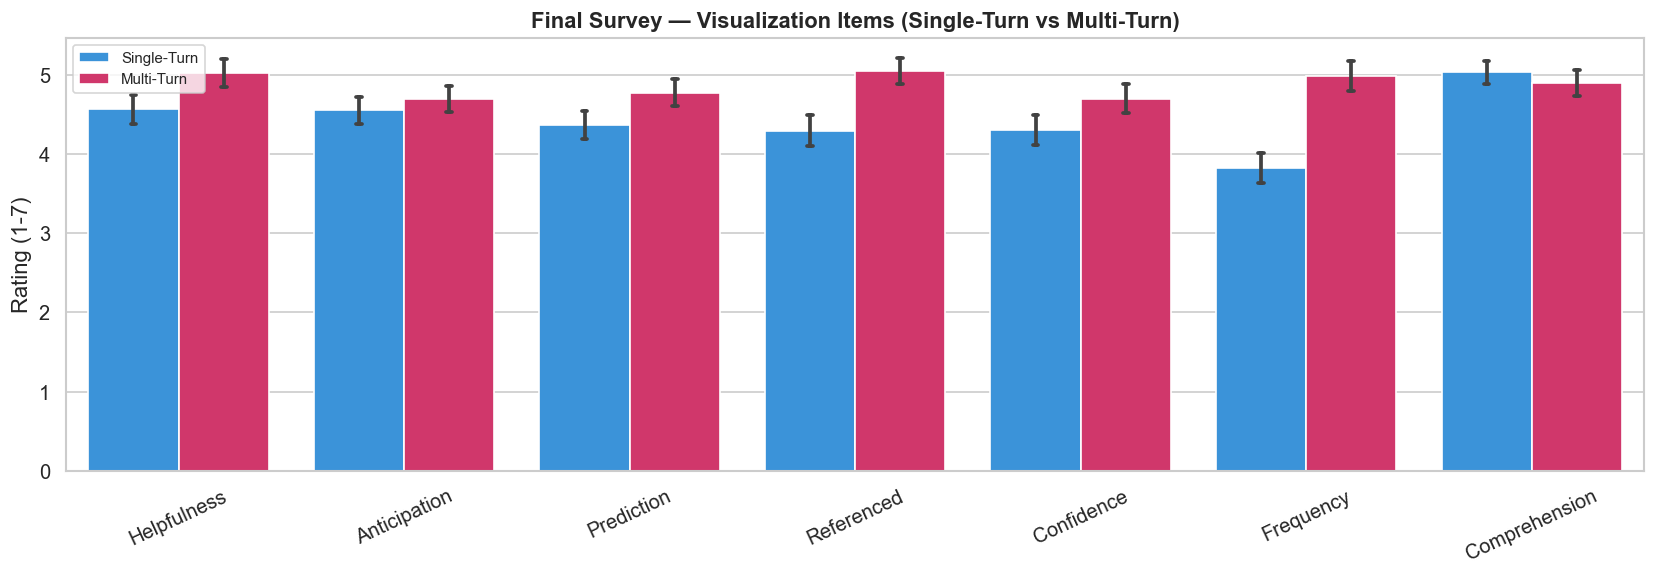

--- Visualization Likert: Single-Turn vs Multi-Turn ---
  Helpfulness    : ST mean=4.56 (n=85) vs MT mean=5.03 (n=80), U=2844, p=0.0629 
  Anticipation   : ST mean=4.55 (n=85) vs MT mean=4.70 (n=80), U=3298, p=0.7336 
  Prediction     : ST mean=4.36 (n=85) vs MT mean=4.78 (n=80), U=2872, p=0.0787 
  Referenced     : ST mean=4.29 (n=85) vs MT mean=5.05 (n=80), U=2588, p=0.0068 *
  Confidence     : ST mean=4.31 (n=85) vs MT mean=4.70 (n=80), U=2960, p=0.1441 
  Frequency      : ST mean=3.82 (n=85) vs MT mean=4.99 (n=80), U=2140, p=0.0000 *
  Comprehension  : ST mean=5.04 (n=85) vs MT mean=4.90 (n=80), U=3553, p=0.6086 

  Drift Panel Helpful (MT only): n=80, mean=4.96, median=5.0, std=1.45


In [9]:
df_viz = df[df['condition_name'].isin(['single_turn', 'multi_turn'])].copy()

viz_cols = ['final_viz_helpfulness', 'final_viz_anticipation', 'final_viz_prediction',
            'final_viz_referenced', 'final_viz_confidence', 'final_viz_frequency',
            'final_viz_comprehension']
viz_labels = ['Helpfulness', 'Anticipation', 'Prediction', 'Referenced',
              'Confidence', 'Frequency', 'Comprehension']

viz_order = ['single_turn', 'multi_turn']
viz_palette = {c: CONDITION_COLORS[c] for c in viz_order}

plot_bars(df_viz, viz_cols, viz_labels,
    'Final Survey — Visualization Items (Single-Turn vs Multi-Turn)',
    'final_viz_likert.png', hue_order=viz_order, palette=viz_palette, figsize=(14, 5))

# Stats
print('--- Visualization Likert: Single-Turn vs Multi-Turn ---')
for col, label in zip(viz_cols, viz_labels):
    st = df_viz[df_viz['condition_name'] == 'single_turn'][col].dropna()
    mt = df_viz[df_viz['condition_name'] == 'multi_turn'][col].dropna()
    u, p = stats.mannwhitneyu(st, mt, alternative='two-sided')
    sig = '*' if p < 0.05 else ''
    print(f'  {label:15s}: ST mean={st.mean():.2f} (n={len(st)}) vs MT mean={mt.mean():.2f} (n={len(mt)}), '
          f'U={u:.0f}, p={p:.4f} {sig}')

drift = df[df['condition_name'] == 'multi_turn']['final_drift_panel_helpful'].dropna()
print(f'\n  Drift Panel Helpful (MT only): n={len(drift)}, mean={drift.mean():.2f}, '
      f'median={drift.median():.1f}, std={drift.std():.2f}')

## 6. UEQ — User Experience Questionnaire (Single-Turn vs Multi-Turn)

8 semantic differential items (1-7). Pragmatic Quality (items 1-4), Hedonic Quality (items 5-8).

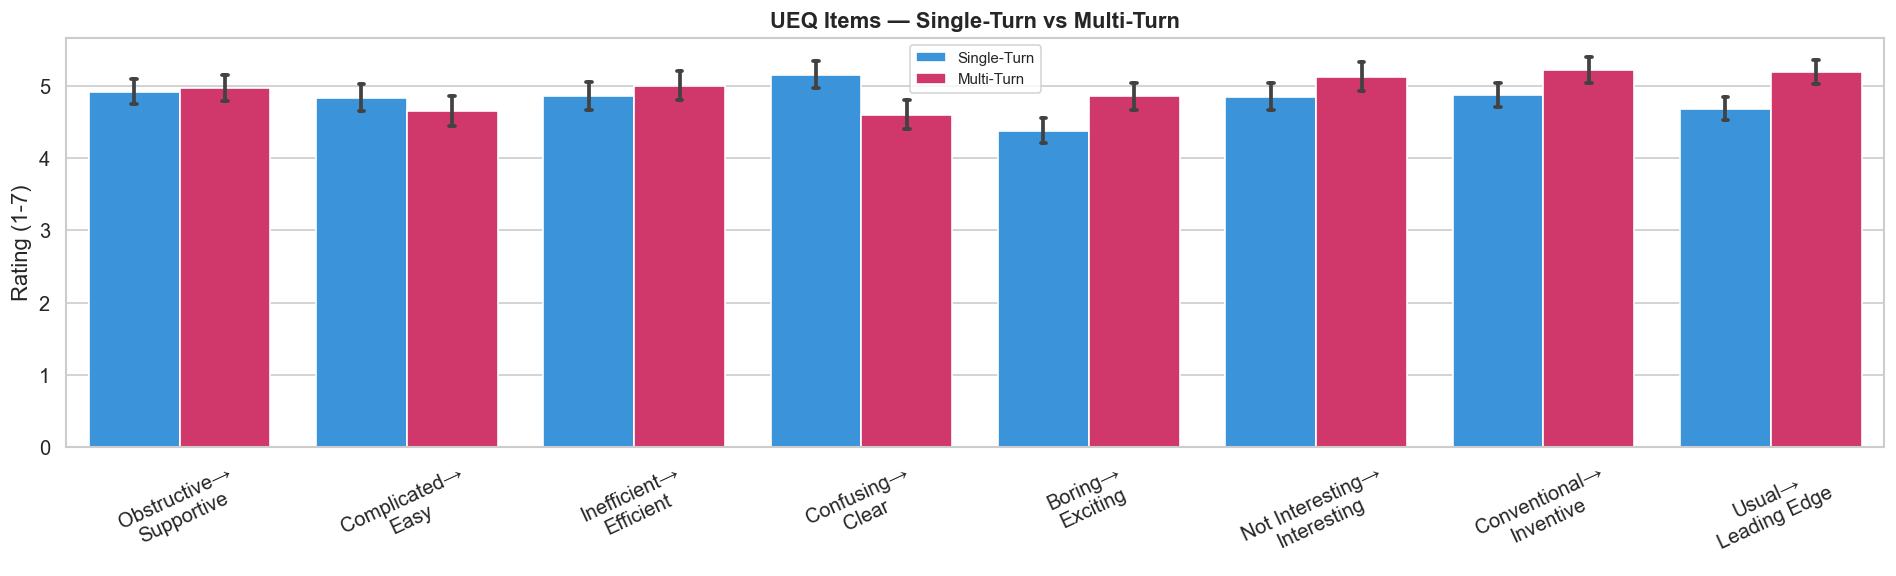

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_66629/3306452083.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='condition_name', y=col, order=viz_order,
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_66629/3306452083.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single-Turn', 'Multi-Turn'])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_66629/3306452083.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='condition_name', y=col, order=viz_order,
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6662

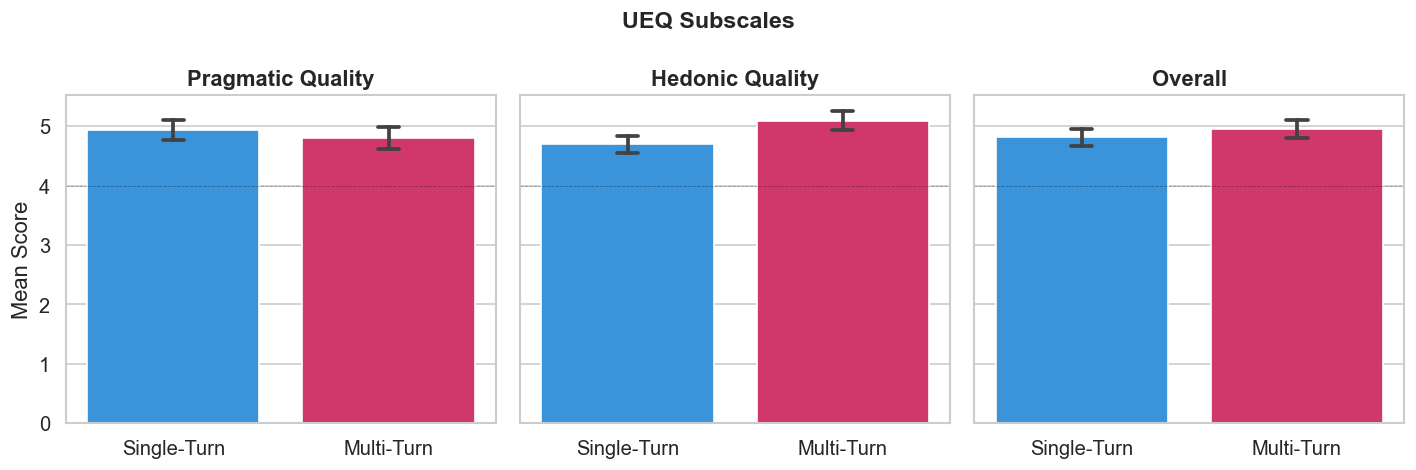

--- UEQ Items ---
  Obstructive→ Supportive       : ST=4.92 vs MT=4.96, U=3340, p=0.8425 
  Complicated→ Easy             : ST=4.84 vs MT=4.65, U=3557, p=0.6039 
  Inefficient→ Efficient        : ST=4.86 vs MT=5.00, U=3260, p=0.6419 
  Confusing→ Clear              : ST=5.15 vs MT=4.60, U=4018, p=0.0403 *
  Boring→ Exciting              : ST=4.38 vs MT=4.85, U=2800, p=0.0459 *
  Not Interesting→ Interesting  : ST=4.85 vs MT=5.12, U=3004, p=0.1878 
  Conventional→ Inventive       : ST=4.87 vs MT=5.21, U=2892, p=0.0912 
  Usual→ Leading Edge           : ST=4.68 vs MT=5.19, U=2673, p=0.0153 *

--- UEQ Subscales ---
  Pragmatic   : ST=4.94 vs MT=4.80, U=3556, p=0.6114 
  Hedonic     : ST=4.69 vs MT=5.09, U=2778, p=0.0424 *
  Overall     : ST=4.82 vs MT=4.95, U=3188, p=0.4912 


In [10]:
ueq_cols = [
    'final_ueq_obstructive_supportive', 'final_ueq_complicated_easy',
    'final_ueq_inefficient_efficient', 'final_ueq_confusing_clear',
    'final_ueq_boring_exciting', 'final_ueq_not_interesting_interesting',
    'final_ueq_conventional_inventive', 'final_ueq_usual_leading_edge',
]
ueq_labels = [
    'Obstructive→\nSupportive', 'Complicated→\nEasy', 'Inefficient→\nEfficient', 'Confusing→\nClear',
    'Boring→\nExciting', 'Not Interesting→\nInteresting', 'Conventional→\nInventive', 'Usual→\nLeading Edge',
]

# Individual items
plot_bars(df_viz, ueq_cols, ueq_labels,
    'UEQ Items — Single-Turn vs Multi-Turn', 'ueq_items.png',
    hue_order=viz_order, palette=viz_palette, figsize=(16, 5))

# Subscales
df_viz['ueq_pragmatic'] = df_viz[ueq_cols[:4]].mean(axis=1)
df_viz['ueq_hedonic'] = df_viz[ueq_cols[4:]].mean(axis=1)
df_viz['ueq_overall'] = df_viz[ueq_cols].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (col, name) in zip(axes, [
    ('ueq_pragmatic', 'Pragmatic Quality'), ('ueq_hedonic', 'Hedonic Quality'), ('ueq_overall', 'Overall')
]):
    sns.barplot(data=df_viz, x='condition_name', y=col, order=viz_order,
                palette=viz_palette, ax=ax, errorbar='se', capsize=0.1)
    ax.set_xticklabels(['Single-Turn', 'Multi-Turn'])
    ax.set_xlabel('')
    ax.set_ylabel('Mean Score' if ax == axes[0] else '')
    ax.set_title(name, fontweight='bold')
    ax.axhline(y=4, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
plt.suptitle('UEQ Subscales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/questionnaire/ueq_subscales.png', bbox_inches='tight')
plt.show()

# Stats
print('--- UEQ Items ---')
for col, label in zip(ueq_cols, ueq_labels):
    st = df_viz[df_viz['condition_name'] == 'single_turn'][col].dropna()
    mt = df_viz[df_viz['condition_name'] == 'multi_turn'][col].dropna()
    u, p = stats.mannwhitneyu(st, mt, alternative='two-sided')
    sig = '*' if p < 0.05 else ''
    print(f'  {label.replace(chr(10), " "):30s}: ST={st.mean():.2f} vs MT={mt.mean():.2f}, U={u:.0f}, p={p:.4f} {sig}')

print('\n--- UEQ Subscales ---')
for col, name in [('ueq_pragmatic', 'Pragmatic'), ('ueq_hedonic', 'Hedonic'), ('ueq_overall', 'Overall')]:
    st = df_viz[df_viz['condition_name'] == 'single_turn'][col].dropna()
    mt = df_viz[df_viz['condition_name'] == 'multi_turn'][col].dropna()
    u, p = stats.mannwhitneyu(st, mt, alternative='two-sided')
    sig = '*' if p < 0.05 else ''
    print(f'  {name:12s}: ST={st.mean():.2f} vs MT={mt.mean():.2f}, U={u:.0f}, p={p:.4f} {sig}')

## 7. Summary Heatmap — All Survey Items by Condition

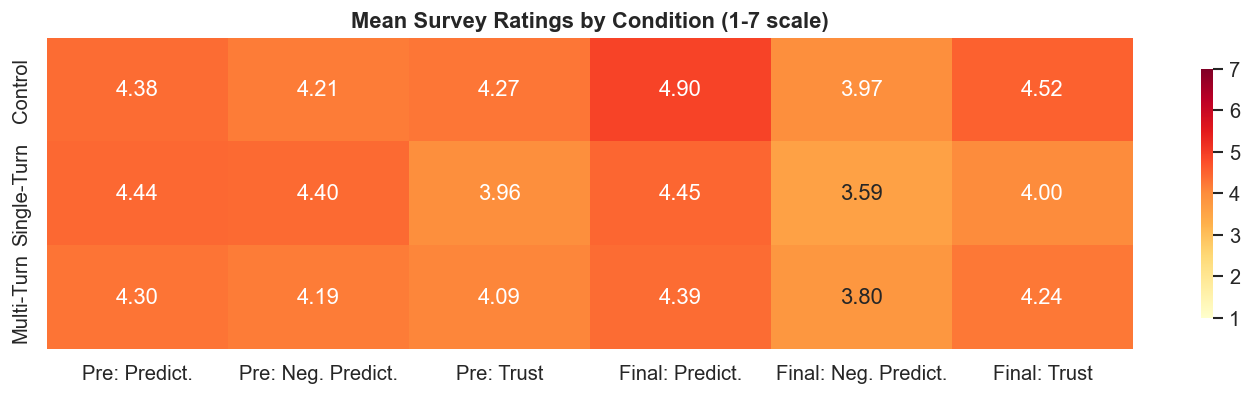

In [11]:
# Core items across all conditions
all_survey_cols = pre_cols + final_cols
all_survey_labels = ['Pre: Predict.', 'Pre: Neg. Predict.', 'Pre: Trust',
                     'Final: Predict.', 'Final: Neg. Predict.', 'Final: Trust']

pivot = df.groupby('condition_name')[all_survey_cols].mean()
pivot.columns = all_survey_labels
row_order = [c for c in CONDITION_ORDER if c in pivot.index]
pivot = pivot.loc[row_order]
pivot.index = [CONDITION_LABELS[c] for c in row_order]

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'shrink': 0.8},
            vmin=1, vmax=7)
ax.set_title('Mean Survey Ratings by Condition (1-7 scale)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plots/questionnaire/heatmap_survey.png', bbox_inches='tight')
plt.show()